# 📊 Notebook 1: Data Understanding

## Goal
Before we clean or analyze any dataset, we first need to **understand what we're working with**. This is the most important step in any data science project — it shapes every decision that follows.

In this notebook we will:
1. Load the dataset and inspect its structure
2. Understand what each column represents
3. Check data types and basic statistics
4. Identify potential data quality issues
5. Formulate business questions for further analysis

---

## 1. Import Libraries

We start by importing the tools we'll use throughout this notebook:
- **pandas** — the core library for data manipulation in Python
- **numpy** — for numerical operations
- **matplotlib & seaborn** — for creating visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for cleaner plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


## 2. Load the Dataset

Our dataset — `vgsales.csv` — contains sales data for over **16,000 video games** across multiple platforms, genres, and regions. It was scraped from [VGChartz](http://www.vgchartz.com/) and is one of the most popular datasets for practising EDA.

> **Why do we look at the first few rows?**  
> The `.head()` method gives us a quick sanity check: do the columns look right? Are the values what we expect?

In [2]:
# Load the raw dataset
df = pd.read_csv('../Data/raw/vgsales.csv')

# Preview the first 5 rows
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
# Preview the last 5 rows to see if the tail looks consistent
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


## 3. Dataset Shape & Column Descriptions

Let's find out how big the dataset is and what each column represents.

| Column | Description |
|---|---|
| `Rank` | Ranking of overall sales (1 = highest) |
| `Name` | Name of the video game |
| `Platform` | Platform of release (e.g., PS4, Wii, X360) |
| `Year` | Year of release |
| `Genre` | Genre of the game (e.g., Action, Sports) |
| `Publisher` | Publisher of the game |
| `NA_Sales` | Sales in North America (millions) |
| `EU_Sales` | Sales in Europe (millions) |
| `JP_Sales` | Sales in Japan (millions) |
| `Other_Sales` | Sales in the rest of the world (millions) |
| `Global_Sales` | Total worldwide sales (millions) |

In [4]:
# How many rows and columns?
print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nThis means we have data on {df.shape[0]:,} video game entries.')

Dataset Shape: 16,598 rows × 11 columns

This means we have data on 16,598 video game entries.


## 4. Data Types & Memory

> **Why check data types?**  
> Incorrect data types can cause errors in calculations. For example, if `Year` is stored as a float instead of an integer, it means there are missing values (NaN can't be stored as int in older pandas versions).

In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [6]:
# Data types summary
print('Data Types:\n')
print(df.dtypes)
print(f'\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

Data Types:

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Memory Usage: 4854.0 KB


### 🔍 Key Observations about Data Types

- `Year` is `float64` instead of `int64` — this tells us there are **missing values** in the Year column (pandas represents integer columns with NaN as float).
- `Name` and `Publisher` are `object` (text) — as expected.
- All sales columns are `float64` — sales are measured in millions with decimal precision.

## 5. Missing Values Analysis

> **Why do missing values matter?**  
> Missing data can skew our analysis. If 50% of years are missing, any "sales trend over time" analysis would be unreliable. We need to know the **extent** of the problem before deciding how to handle it.

In [7]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print('Missing Values Summary:\n')
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal rows with at least one missing value: {df.isnull().any(axis=1).sum()}')

Missing Values Summary:

           Missing Count  Missing %
Year                 271       1.63
Publisher             58       0.35

Total rows with at least one missing value: 307


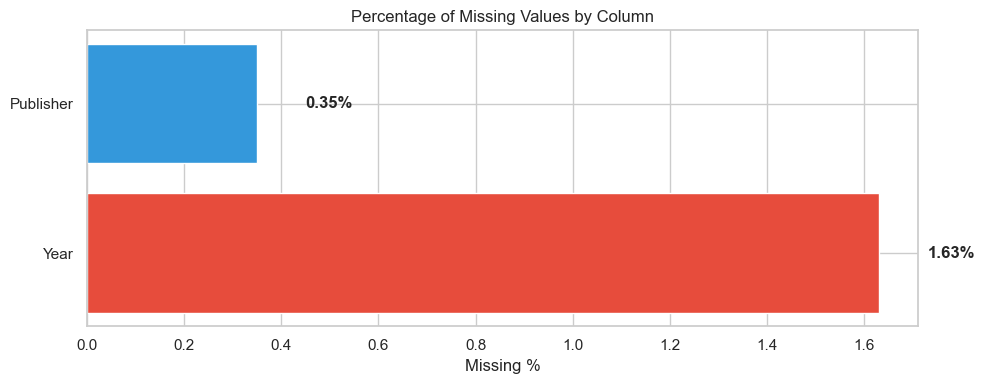

In [8]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
ax.barh(cols_with_missing.index, cols_with_missing['Missing %'], color=['#e74c3c', '#3498db'])
ax.set_xlabel('Missing %')
ax.set_title('Percentage of Missing Values by Column')
for i, v in enumerate(cols_with_missing['Missing %']):
    ax.text(v + 0.1, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary Statistics

> **Why use `.describe()`?**  
> Summary statistics reveal the **distribution** of numerical data at a glance — min, max, mean, median (50%), and spread (std). Outliers often show up as a huge gap between the 75th percentile and the max.

In [9]:
# Summary statistics for numerical columns
df.describe().round(2)

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.00,16327.00,16598.00,16598.00,16598.00,16598.00,16598.00
mean,8300.61,2006.41,0.26,0.15,0.08,0.05,0.54
std,4791.85,5.83,0.82,0.51,0.31,0.19,1.56
min,1.00,1980.00,0.00,0.00,0.00,0.00,0.01
25%,4151.25,2003.00,0.00,0.00,0.00,0.00,0.06
50%,8300.50,2007.00,0.08,0.02,0.00,0.01,0.17
75%,12449.75,2010.00,0.24,0.11,0.04,0.04,0.47
max,16600.00,2020.00,41.49,29.02,10.22,10.57,82.74


In [10]:
# Summary statistics for categorical columns
df.describe(include='object')

,Name,Platform,Genre,Publisher
count,16598,16598,16598,16540
unique,11493,31,12,578
top,Need for Speed: Most Wanted,DS,Action,Electronic Arts
freq,12,2163,3316,1351


### 🔍 Key Observations from Summary Statistics

- **Global Sales**: The average game sells **0.54M copies**, but the maximum is **82.74M** (Wii Sports). This shows a **highly skewed** distribution — a few mega-hits dominate.
- **NA_Sales** has the highest mean among regions, suggesting North America is the **largest single market**.
- **JP_Sales** has a lower mean but still significant — Japan has a very different gaming culture.
- **Year** ranges from 1980 to 2020, covering **four decades** of gaming history.
- There are **31 platforms** and **12 genres** to explore.

## 7. Exploring Categorical Columns

Let's look at the unique values in our key categorical columns to understand the diversity of the data.

In [11]:
# Unique counts
print('Unique Value Counts:')
print(f'  Platforms:  {df["Platform"].nunique()}')
print(f'  Genres:     {df["Genre"].nunique()}')
print(f'  Publishers: {df["Publisher"].nunique()}')
print(f'  Games:      {df["Name"].nunique()}')

Unique Value Counts:
  Platforms:  31
  Genres:     12
  Publishers: 578
  Games:      11493


In [12]:
# All genres in the dataset
print('Genres:')
print(df['Genre'].value_counts())

Genres:
Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64


In [13]:
# Top 15 platforms by number of games
print('Top 15 Platforms by Game Count:')
print(df['Platform'].value_counts().head(15))

Top 15 Platforms by Game Count:
Platform
DS      2163
PS2     2161
PS3     1329
Wii     1325
X360    1265
PSP     1213
PS      1196
PC       960
XB       824
GBA      822
GC       556
3DS      509
PSV      413
PS4      336
N64      319
Name: count, dtype: int64


In [14]:
# Top 15 publishers by number of games
print('Top 15 Publishers by Game Count:')
print(df['Publisher'].value_counts().head(15))

Top 15 Publishers by Game Count:
Publisher
Electronic Arts                           1351
Activision                                 975
Namco Bandai Games                         932
Ubisoft                                    921
Konami Digital Entertainment               832
THQ                                        715
Nintendo                                   703
Sony Computer Entertainment                683
Sega                                       639
Take-Two Interactive                       413
Capcom                                     381
Atari                                      363
Tecmo Koei                                 338
Square Enix                                233
Warner Bros. Interactive Entertainment     232
Name: count, dtype: int64


## 8. Initial Visualizations

Let's create a few simple plots to start building intuition about the data.

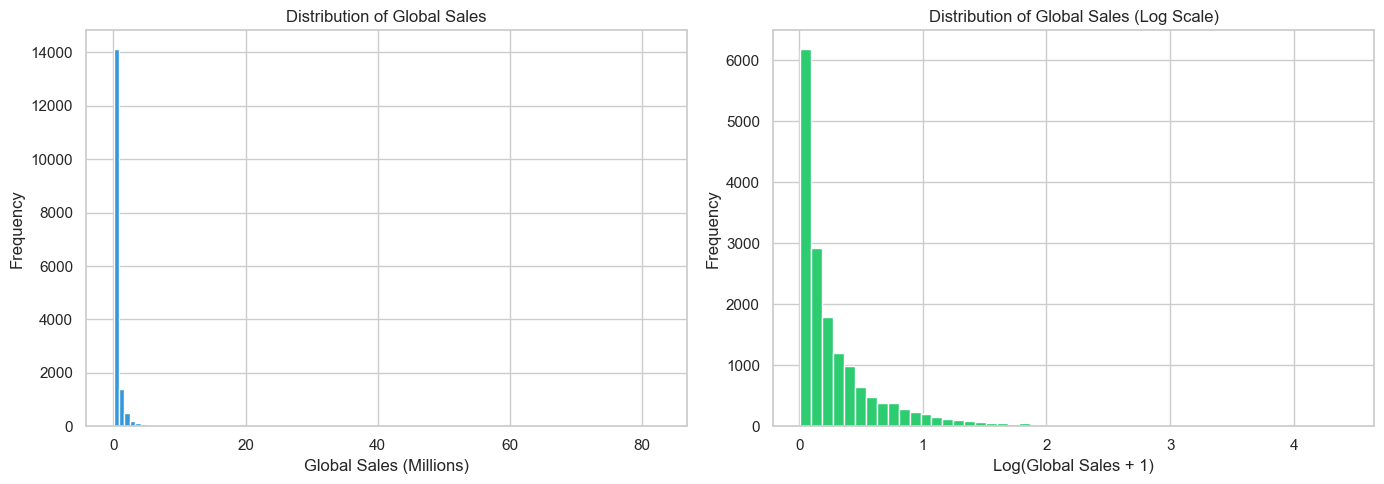

💡 Insight: The vast majority of games sell under 1 million copies.
   Games selling < 1M: 14,517 (87.5%)
   Games selling > 10M: 62 (0.4%)


In [15]:
# Distribution of Global Sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution (very skewed)
axes[0].hist(df['Global_Sales'], bins=100, color='#3498db', edgecolor='white')
axes[0].set_title('Distribution of Global Sales')
axes[0].set_xlabel('Global Sales (Millions)')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution
axes[1].hist(np.log1p(df['Global_Sales']), bins=50, color='#2ecc71', edgecolor='white')
axes[1].set_title('Distribution of Global Sales (Log Scale)')
axes[1].set_xlabel('Log(Global Sales + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('💡 Insight: The vast majority of games sell under 1 million copies.')
print(f'   Games selling < 1M: {(df["Global_Sales"] < 1).sum():,} ({(df["Global_Sales"] < 1).mean()*100:.1f}%)')
print(f'   Games selling > 10M: {(df["Global_Sales"] > 10).sum():,} ({(df["Global_Sales"] > 10).mean()*100:.1f}%)')

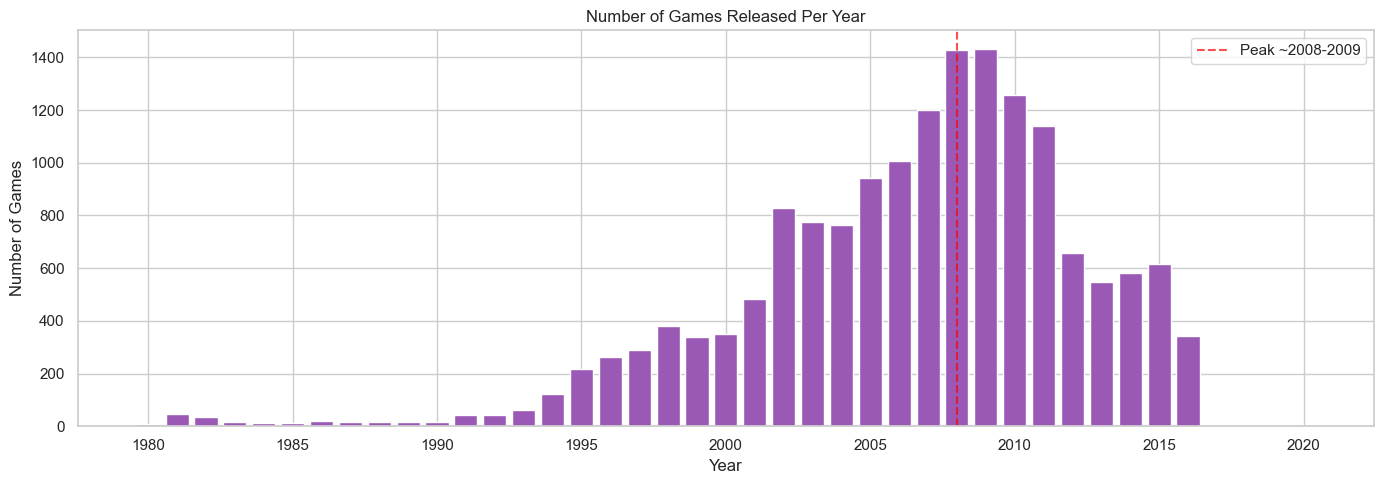

💡 Insight: Game releases peaked around 2008-2009, likely driven by the PS3/X360/Wii generation.
   After 2010, the count drops — partly because the dataset may not fully cover later years.


In [16]:
# Number of games released per year
yearly_counts = df.dropna(subset=['Year']).groupby('Year').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(yearly_counts.index, yearly_counts.values, color='#9b59b6', edgecolor='white', width=0.8)
ax.set_title('Number of Games Released Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games')
ax.axvline(x=2008, color='red', linestyle='--', alpha=0.7, label='Peak ~2008-2009')
ax.legend()
plt.tight_layout()
plt.show()

print('💡 Insight: Game releases peaked around 2008-2009, likely driven by the PS3/X360/Wii generation.')
print('   After 2010, the count drops — partly because the dataset may not fully cover later years.')

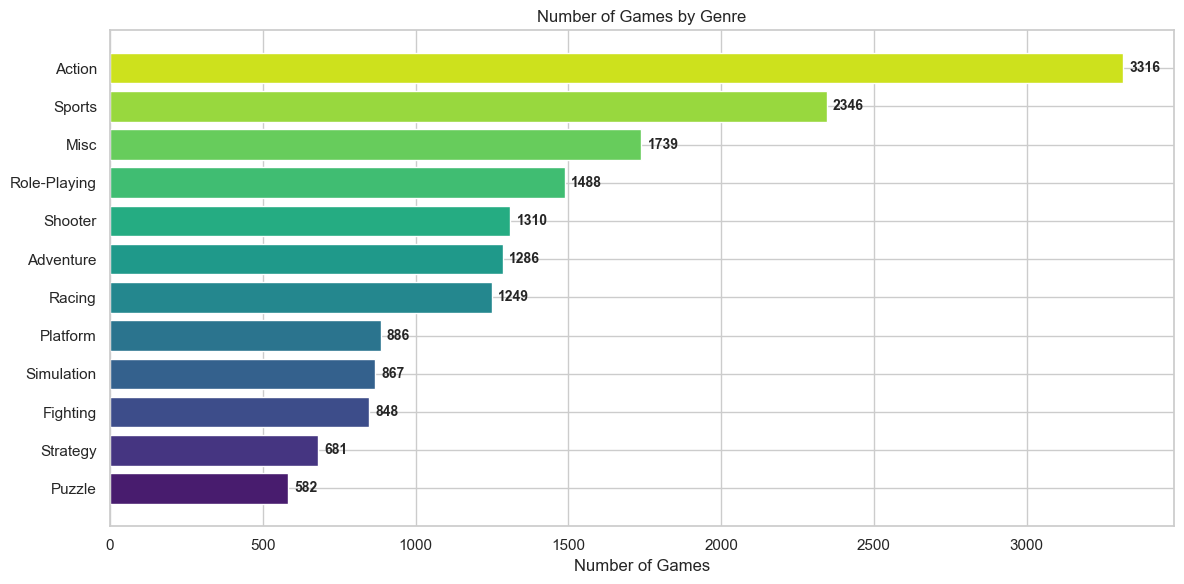

💡 Insight: Action is the most common genre, followed by Sports and Misc.
   Strategy and Puzzle games are the least common — niche markets.


In [17]:
# Genre distribution
fig, ax = plt.subplots(figsize=(12, 6))
genre_counts = df['Genre'].value_counts()
colors = sns.color_palette('viridis', len(genre_counts))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=colors)
ax.set_title('Number of Games by Genre')
ax.set_xlabel('Number of Games')
for i, v in enumerate(genre_counts.values[::-1]):
    ax.text(v + 20, i, str(v), va='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

print('💡 Insight: Action is the most common genre, followed by Sports and Misc.')
print('   Strategy and Puzzle games are the least common — niche markets.')

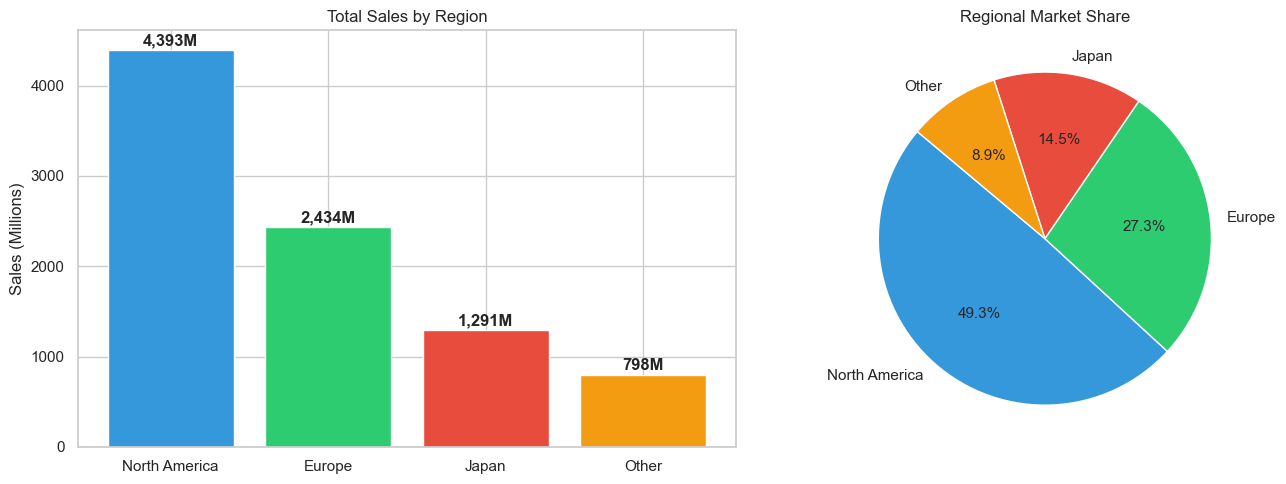

💡 Insight: North America is the largest market (~49%), followed by Europe (~27%).
   Japan accounts for ~13% — smaller but culturally significant (RPGs, Nintendo).


In [18]:
# Regional sales comparison
regional_totals = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
regional_totals.index = ['North America', 'Europe', 'Japan', 'Other']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
axes[0].bar(regional_totals.index, regional_totals.values, color=colors)
axes[0].set_title('Total Sales by Region')
axes[0].set_ylabel('Sales (Millions)')
for i, v in enumerate(regional_totals.values):
    axes[0].text(i, v + 50, f'{v:,.0f}M', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(regional_totals, labels=regional_totals.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Regional Market Share')

plt.tight_layout()
plt.show()

print('💡 Insight: North America is the largest market (~49%), followed by Europe (~27%).')
print('   Japan accounts for ~13% — smaller but culturally significant (RPGs, Nintendo).')

## 9. Business Questions for Further Analysis

Based on our initial exploration, here are the key questions we'll investigate in the **EDA notebook**:

1. **Genre Analysis**: Which genres generate the most revenue? Has this changed over time?
2. **Platform Wars**: Which platforms sold the most games? How do their lifecycles compare?
3. **Regional Preferences**: Do different regions prefer different genres or platforms?
4. **Publisher Dominance**: Which publishers control the market? Is it concentrated or diverse?
5. **Time Trends**: How did the gaming market grow and evolve across decades?
6. **Top Games**: What makes a game a mega-hit? Any common traits among top sellers?
7. **Market Evolution**: How did the shift from cartridge to disc to digital affect the market?

---

## 10. Summary

| Aspect | Finding |
|---|---|
| **Dataset Size** | 16,598 games, 11 columns |
| **Time Span** | 1980–2020 (peak releases around 2008) |
| **Platforms** | 31 unique platforms |
| **Genres** | 12 genres (Action most common) |
| **Publishers** | 578+ publishers |
| **Missing Data** | ~271 missing years, ~58 missing publishers |
| **Sales Distribution** | Highly skewed — most games sell < 1M copies |
| **Largest Market** | North America (~49% of global sales) |

### Next Steps
In **Notebook 02**, we will clean this data — handle missing values, fix data types, and prepare a clean dataset for analysis.